<a href="https://colab.research.google.com/github/noureldin75/RetinaGrade/blob/nour/nootbooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

if os.path.exists('/content/RetinaGrade'):
    %cd /content/RetinaGrade
    !git pull origin nour
else:
    !git clone -b nour https://github.com/noureldin75/RetinaGrade.git
    %cd RetinaGrade

Cloning into 'RetinaGrade'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 381 (delta 69), reused 85 (delta 33), pack-reused 227 (from 1)
Receiving objects: 100% (381/381), 16.02 MiB | 14.34 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/RetinaGrade


In [2]:
!mkdir -p data notebooks src

In [3]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection -p ./data

!unzip -q ./data/aptos2019-blindness-detection.zip -d ./data

100% 9.51G/9.51G [01:16<00:00, 133MB/s]



In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

train_df=pd.read_csv('./data/train.csv')
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"Missing values: {train_df.isnull().sum()}\n")
print(train_df.head())


Shape: (3662, 2)
Columns: ['id_code', 'diagnosis']
Missing values: id_code      0
diagnosis    0
dtype: int64

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [5]:
print(f"{train_df['diagnosis'].value_counts().sort_index()}")


diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [6]:
# --- Verify every listed image actually exists on disk ---
image_dir = './data/train_images'
missing_files = []

for img_id in train_df['id_code']:
    # APTOS images are .png
    path = os.path.join(image_dir, f"{img_id}.png")
    if not os.path.exists(path):
        missing_files.append(img_id)

print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])  # show a sample


Images listed in CSV: 3662
Missing image files: 0


In [7]:
image_dir='./data/train_images'
missing_images=[]
for id in train_df['id_code']:
  path=os.path.join(image_dir,f"{id}.png")
  if not os.path.exists(path):
    missing_files.append(id)
print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")


Images listed in CSV: 3662
Missing image files: 0


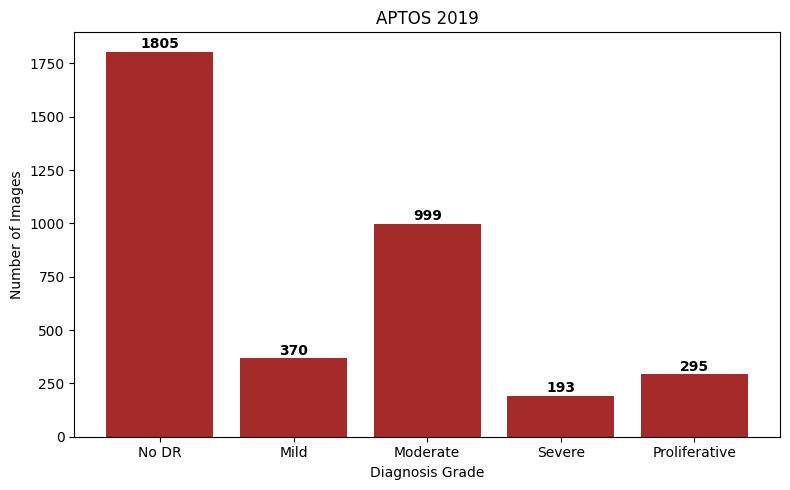

In [8]:
import matplotlib.pyplot as plt

grade_labels = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative'
}

counts = train_df['diagnosis'].value_counts().sort_index()
labels=[]
for i in counts.index:
  labels.append(grade_labels[i])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts.values, color='brown')
ax.set_xlabel('Diagnosis Grade')
ax.set_ylabel('Number of Images')
ax.set_title('APTOS 2019')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



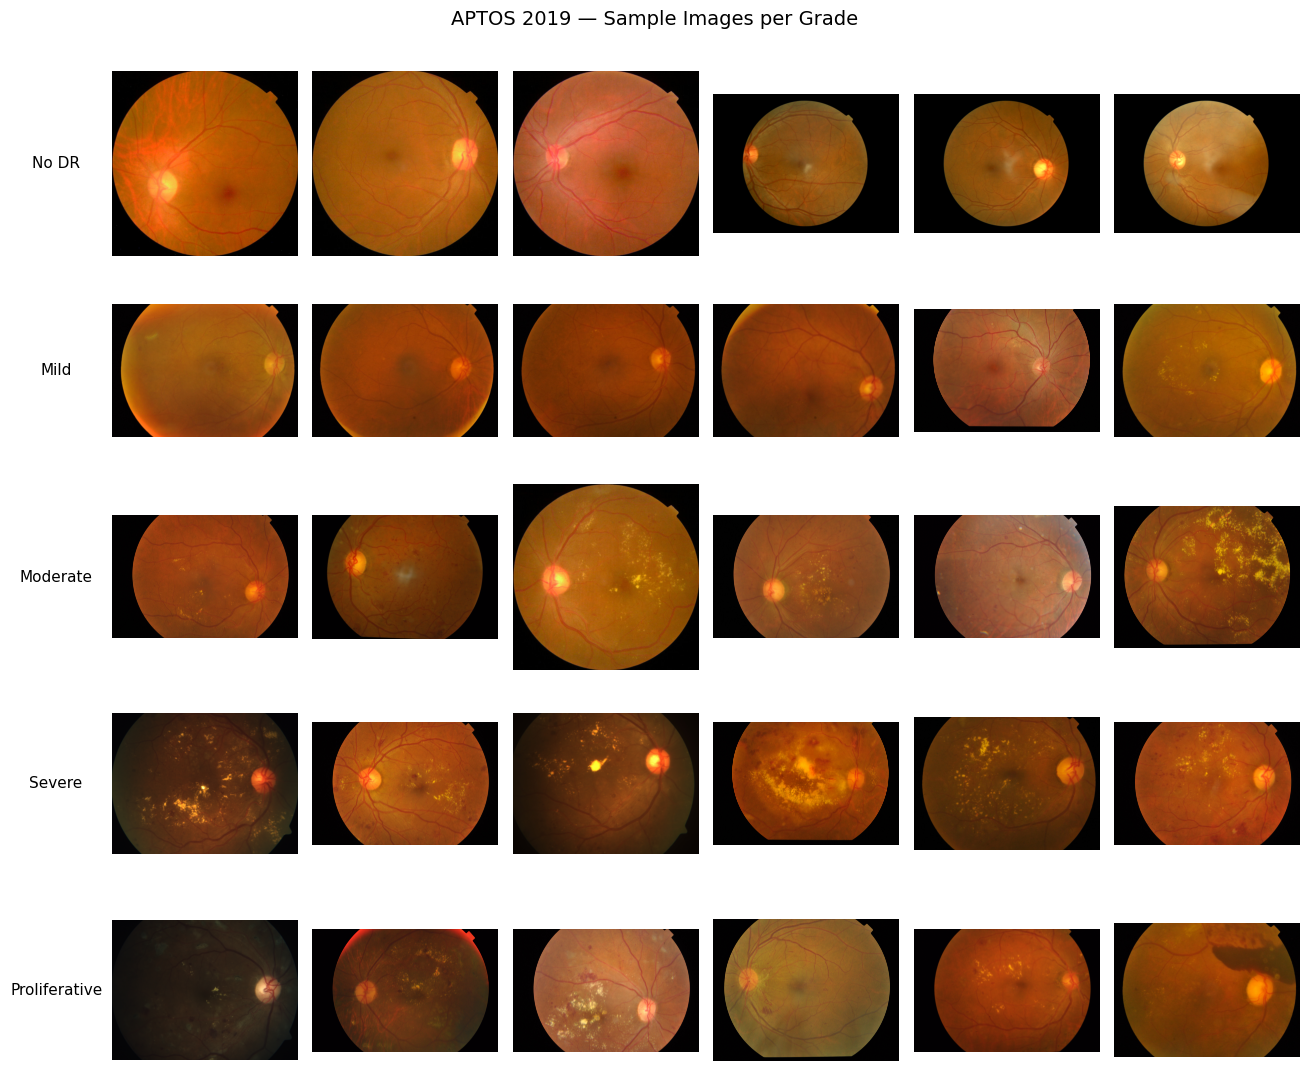

In [9]:
import numpy as np
from PIL import Image

n_samples = 6  # images per class
grades = sorted(grade_labels.keys())

fig, axes = plt.subplots(len(grades), n_samples, figsize=(n_samples * 2.2, len(grades) * 2.2))

rng = np.random.default_rng(42)  # reproducible sampling

for row, grade in enumerate(grades):
    # Get all image ids for this grade
    subset = train_df[train_df['diagnosis'] == grade]['id_code'].values
    sample_ids = rng.choice(subset, size=min(n_samples, len(subset)), replace=False)

    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(image_dir, f"{img_id}.png")
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(grade_labels[grade], fontsize=11, rotation=0,
                          labelpad=40, va='center')
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle('APTOS 2019 — Sample Images per Grade', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [10]:
from PIL import Image
import os

sizes = []

for img_id in train_df['id_code']:
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        sizes.append(img.size)

print("First 10 image sizes:")
print(sizes[:10])

print("\nUnique image sizes:")
print(len(set(sizes)))

First 10 image sizes:
[(3216, 2136), (3216, 2136), (2416, 1736), (1050, 1050), (2048, 1536), (3388, 2588), (2588, 1958), (3216, 2136), (2588, 1958), (2416, 1736)]

Unique image sizes:
17


In [11]:
modes = []

for img_id in train_df['id_code'].sample(100, random_state=42):
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        modes.append(img.mode)

print(set(modes))

{'RGB'}


In [12]:
import sys
sys.path.append('/content/RetinaGrade/src/preprocessing')


from preprocessor import RetinaPreprocessor
from quality_checker import ImageQualityAssessor

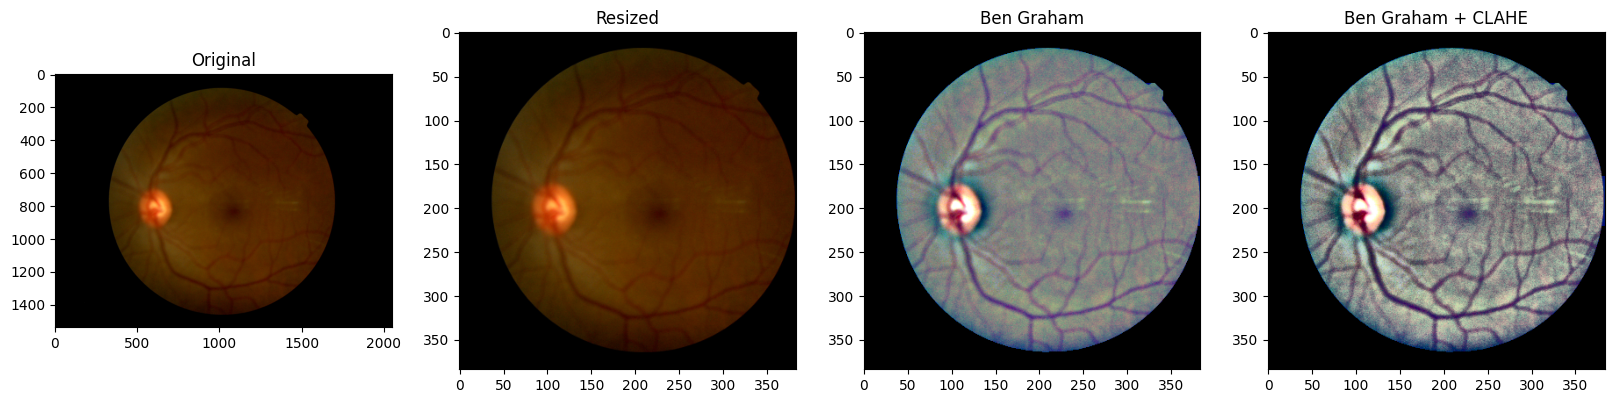

In [13]:
preprocessor = RetinaPreprocessor(img_size=384, ben_graham_sigma=10)
stages = preprocessor.preprocess_for_visualization('/content/RetinaGrade/data/train_images/005b95c28852.png')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(stages['original']); axes[0].set_title('Original')
axes[1].imshow(stages['resized']); axes[1].set_title('Resized')
axes[2].imshow(stages['ben_graham']); axes[2].set_title('Ben Graham')
axes[3].imshow(stages['ben_graham_clahe']); axes[3].set_title('Ben Graham + CLAHE')
plt.show()

# **Add processed images**

In [14]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil


INPUT_DIR = '/content/RetinaGrade/data/train_images/'
GOOD_OUTPUT_DIR = '/content/RetinaGrade/data/processed_train_images/'
REJECTED_DIR = '/content/RetinaGrade/data/rejected_images/'

if os.path.exists(GOOD_OUTPUT_DIR):
    shutil.rmtree(GOOD_OUTPUT_DIR)
if os.path.exists(REJECTED_DIR):
    shutil.rmtree(REJECTED_DIR)

os.makedirs(GOOD_OUTPUT_DIR, exist_ok=True)
os.makedirs(REJECTED_DIR, exist_ok=True)

assessor = ImageQualityAssessor()
preprocessor = RetinaPreprocessor(img_size=300)

QUALITY_THRESHOLD = 0.25

valid_extensions = ('.png', '.jpg', '.jpeg')
all_images = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(valid_extensions)]

print(f" Starting processing of {len(all_images)} images with a lenient threshold ({QUALITY_THRESHOLD})...")

accepted_count = 0
rejected_count = 0

for img_name in tqdm(all_images, desc="Processing Images"):
    img_path = os.path.join(INPUT_DIR, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    score, issues = assessor.assess_quality(img)

    if score >= QUALITY_THRESHOLD:
        processed_img = preprocessor.preprocess_array(img, return_tensor=False, is_rgb=False)
        processed_img_uint8 = (processed_img * 255).astype(np.uint8)

        final_img_bgr = cv2.cvtColor(processed_img_uint8, cv2.COLOR_RGB2BGR)

        save_path = os.path.join(GOOD_OUTPUT_DIR, img_name)
        cv2.imwrite(save_path, final_img_bgr)
        accepted_count += 1

    else:
        dest_path = os.path.join(REJECTED_DIR, img_name)
        shutil.copy(img_path, dest_path)
        rejected_count += 1


print("\n" + "="*40)
print(" Process completed successfully!")
print(f" Total images: {len(all_images)}")
print(f" Accepted & Processed images: {accepted_count} (Saved to {GOOD_OUTPUT_DIR})")
print(f" Rejected images: {rejected_count} (Isolated to {REJECTED_DIR})")
print("="*40)

 Starting processing of 3662 images with a lenient threshold (0.25)...


Processing Images: 100%|██████████| 3662/3662 [11:53<00:00,  5.13it/s]


 Process completed successfully!
 Total images: 3662
 Accepted & Processed images: 3662 (Saved to /content/RetinaGrade/data/processed_train_images/)
 Rejected images: 0 (Isolated to /content/RetinaGrade/data/rejected_images/)


In [15]:
!ls data/processed_train_images | head


000c1434d8d7.png
001639a390f0.png
0024cdab0c1e.png
002c21358ce6.png
005b95c28852.png
0083ee8054ee.png
0097f532ac9f.png
00a8624548a9.png
00b74780d31d.png
00cb6555d108.png


In [16]:
from utils import load_data,data_split
import gc
x_train,y_train=load_data(df=train_df, image_dir="./data/processed_train_images")
x_train,x_val,x_test,y_train,y_val,y_test=data_split(x_train,y_train,val_size=0.2,test_size=0.0)



In [17]:

print(y_train[0])

0


In [18]:
import torch
from model_builder import build_model
model=build_model(model_name="efficientnet_b3", num_classes=5, freeze_features=True)

device= "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 105MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [19]:
print(len(model.features))

9


#Defining Weighted Loss

In [20]:
from Loss import FocalLoss
#convert to dict[] but i cant run it to test
W_loss=np.zeros(5)
for y in y_train:
  W_loss[y]+=1
W_loss=1/(W_loss/len(y_train))
W_loss=torch.tensor(W_loss,dtype=torch.float32).to(device)
# loss_function=nn.CrossEntropyLoss() #Remember to put it
loss_function=FocalLoss(gamma=2.0)


# Optimizer setup


In [21]:
import torch.optim as optim
import torch.utils.data as data
#best lr: 1e-3
lr=1e-3
weight_decay=5e-4
optimizer=optim.Adam(model.classifier.parameters(),lr=lr, weight_decay=weight_decay)

#Getting Data Ready and Augumented


In [22]:
from augumentation import over_sample, train_transform,val_transform,apply_transform
from augumented_set import AugmentedDataset
from data_loading import create_dataloaders
train_loader,val_loader,test_loader =create_dataloaders(x_train,
                                                        y_train,
                                                        x_val, y_val,
                                                        x_test,
                                                        y_test,
                                                        targets={1: 2, 2: 2, 3: 7, 4: 5},
                                                        batch_size=32,
                                                        num_workers=4
                                                        )


/content/RetinaGrade/src/preprocessing/augumentation.py:44: UserWarning: Argument(s) 'alpha_limit' are not valid for transform Sharpen
  A.Sharpen(alpha_limit=0.2, p=1.0),
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


#See Some Augumented Examples


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


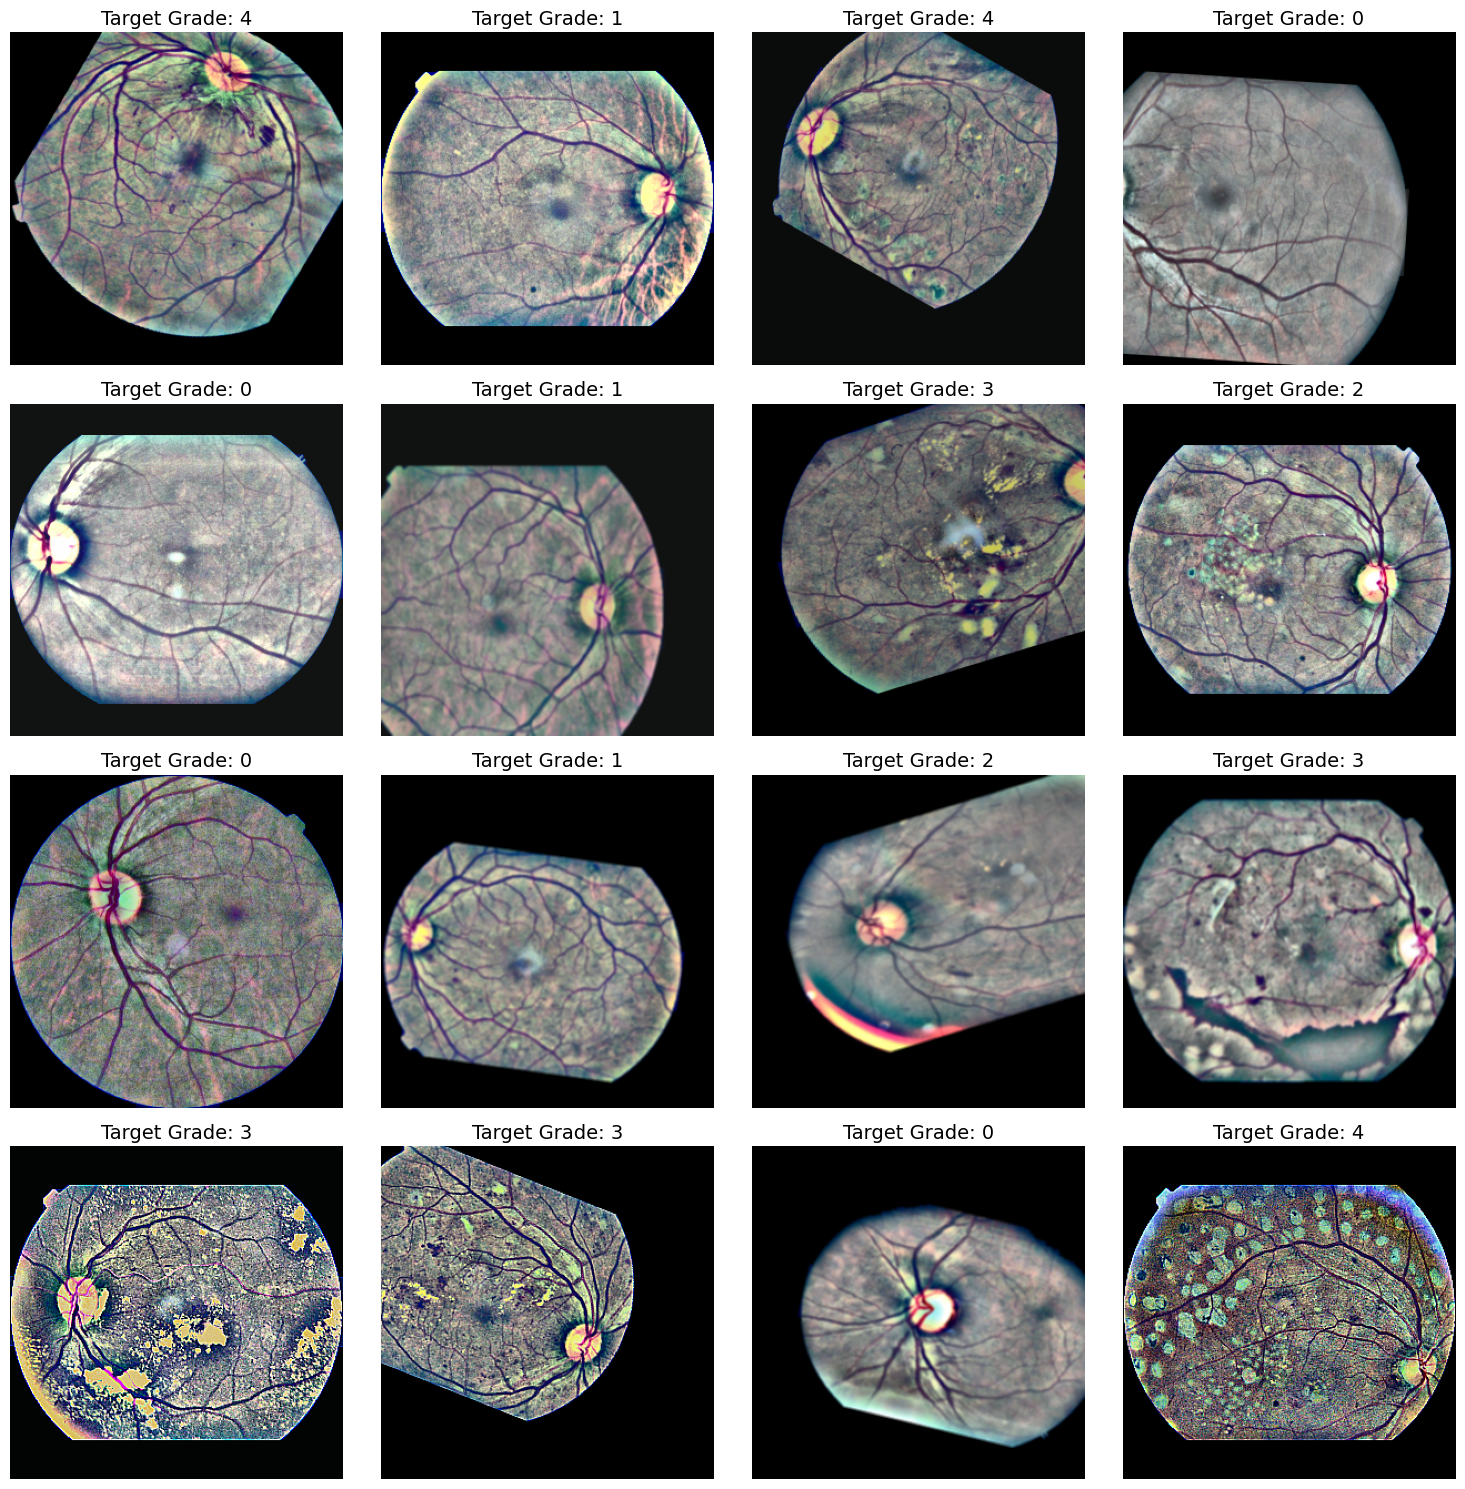

In [23]:
from ploting_util import plot_augmented_batch

plot_augmented_batch(train_loader, num_images=16)

In [24]:
#  del x_train, y_train,
#  gc.collect()


#Training BaseLine


Epoch 1/30 - train_loss: 1.0177 - val_loss: 0.6665
  val macro F1: 0.4129 | val QWK: 0.6833
  current LR: 1.00e-03
  -> Best model saved (max: 0.6833)
Epoch 2/30 - train_loss: 0.8504 - val_loss: 0.4870
  val macro F1: 0.4585 | val QWK: 0.7345
  current LR: 1.00e-03
  -> Best model saved (max: 0.7345)
Epoch 3/30 - train_loss: 0.7673 - val_loss: 0.5727
  val macro F1: 0.4016 | val QWK: 0.7736
  current LR: 1.00e-03
  -> Best model saved (max: 0.7736)
Epoch 4/30 - train_loss: 0.7558 - val_loss: 0.5445
  val macro F1: 0.4083 | val QWK: 0.7055
  current LR: 1.00e-03
Epoch 5/30 - train_loss: 0.7851 - val_loss: 0.6668
  val macro F1: 0.5144 | val QWK: 0.7195
  current LR: 1.00e-03
Epoch 6/30 - train_loss: 0.7710 - val_loss: 0.4221
  val macro F1: 0.5007 | val QWK: 0.7878
  current LR: 1.00e-03
  -> Best model saved (max: 0.7878)
Epoch 7/30 - train_loss: 0.7375 - val_loss: 0.4434
  val macro F1: 0.5020 | val QWK: 0.7557
  current LR: 1.00e-03
Epoch 8/30 - train_loss: 0.7903 - val_loss: 0.5315


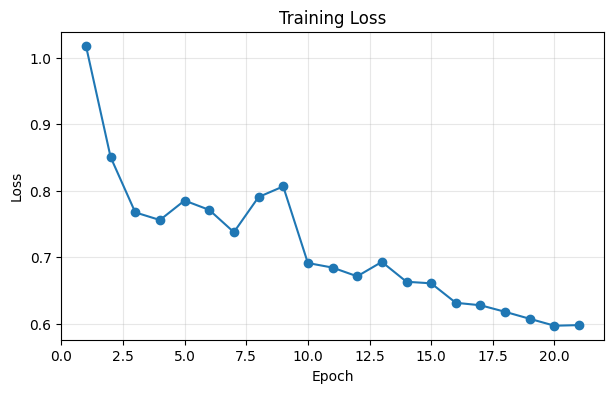

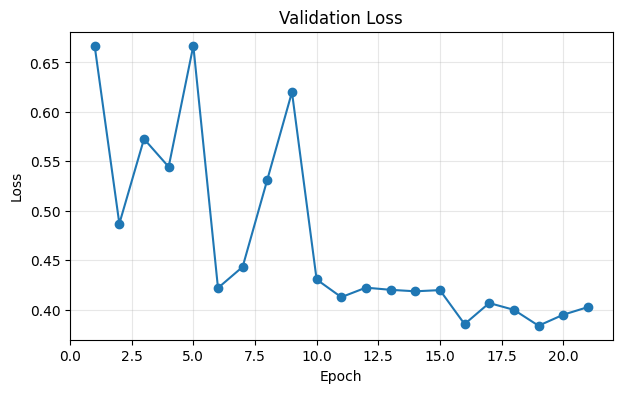

Accuracy:  0.7149
F1 (macro):     0.5388
Recall (macro): 0.5436
Precision (macro): 0.5458
QWK:       0.7887

Per-class report:
               precision    recall  f1-score   support

        No DR       0.94      0.94      0.94       361
         Mild       0.32      0.50      0.39        74
     Moderate       0.66      0.57      0.61       200
       Severe       0.39      0.38      0.39        39
Proliferative       0.41      0.32      0.36        59

     accuracy                           0.71       733
    macro avg       0.55      0.54      0.54       733
 weighted avg       0.73      0.71      0.72       733



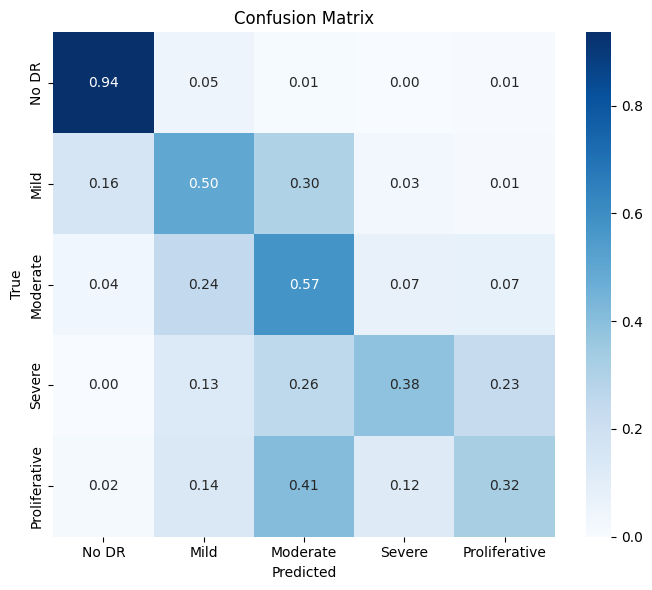

In [ ]:
!pip install coral-pytorch -q
from evalution import evaluate_model, plot_training_curve, get_predictions, compute_metrics, compute_qwk
from early_stopper import EarlyStopping

import os
os.makedirs('/RetinaGrade/CheckPoint', exist_ok=True)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

early_stopper = EarlyStopping(patience=5, min_delta=0.001, path='/RetinaGrade/CheckPoint/best_model.pt', mode='max')

train_losses = []
val_losses = []
epoches = 30

for epoch in range(epoches):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{epoches} "
        f"- train_loss: {avg_train_loss:.4f} "
        f"- val_loss: {avg_val_loss:.4f}"
    )

    y_pred, y_true = get_predictions(model, val_loader, device)
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler.step(val_qwk)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  current LR: {current_lr:.2e}")

    early_stopper(val_qwk, model)

    if early_stopper.early_stop:
        print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper.best_score:.4f})")
        break

plot_training_curve(train_losses, title="Training Loss")
plot_training_curve(val_losses, title="Validation Loss")
metrics = evaluate_model(model, val_loader, device, average="macro")

In [ ]:
from LR_Tune import tune_learning_rates

lr_candidates = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]
tuning_results = tune_learning_rates(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    device=device,
    lrs=lr_candidates,
    epochs=6
)


--- Testing Learning Rate: 1e-05 ---


KeyboardInterrupt: 

#WD


In [ ]:
from WD_tune import tune_weight_decay

wd_candidates = [0, 1e-4, 1e-3, 1e-2, 5e-2]
tuning_results = tune_weight_decay(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    device=device,
    lr=1e-3,
    weight_decays=wd_candidates,
    epochs=6
)

# unfreeze


In [ ]:
model.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model.pt'))

for layer_idx in [6, 7, 8]:
    for param in model.features[layer_idx].parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

optimizer = optim.Adam([
    {'params': model.classifier.parameters(), 'lr': 1e-4},
    {'params': model.features[6].parameters(), 'lr': 1e-5},
    {'params': model.features[7].parameters(), 'lr': 1e-5},
    {'params': model.features[8].parameters(), 'lr': 1e-4},
], weight_decay=5e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
early_stopper = EarlyStopping(patience=10, min_delta=0.001, path='/RetinaGrade/CheckPoint/best_model_finetuned.pt', mode='max')

Trainable params: 8,513,764 / 10,703,918 (79.5%)


Epoch 1/40 - train_loss: 0.5845 - val_loss: 0.3662
  val macro F1: 0.5497 | val QWK: 0.8236
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8236)
Epoch 2/40 - train_loss: 0.5238 - val_loss: 0.3820
  val macro F1: 0.5431 | val QWK: 0.8066
  current LR (classifier): 1.00e-04
Epoch 3/40 - train_loss: 0.4846 - val_loss: 0.3403
  val macro F1: 0.5987 | val QWK: 0.8515
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8515)
Epoch 4/40 - train_loss: 0.4647 - val_loss: 0.3280
  val macro F1: 0.6134 | val QWK: 0.8459
  current LR (classifier): 1.00e-04
Epoch 5/40 - train_loss: 0.4437 - val_loss: 0.3252
  val macro F1: 0.6228 | val QWK: 0.8472
  current LR (classifier): 1.00e-04
Epoch 6/40 - train_loss: 0.4188 - val_loss: 0.3187
  val macro F1: 0.6250 | val QWK: 0.8648
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8648)
Epoch 7/40 - train_loss: 0.4196 - val_loss: 0.3150
  val macro F1: 0.6436 | val QWK: 0.8582
  current LR (classifier): 1.00e

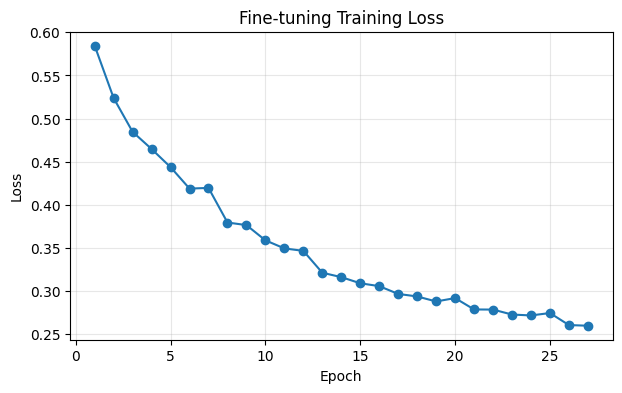

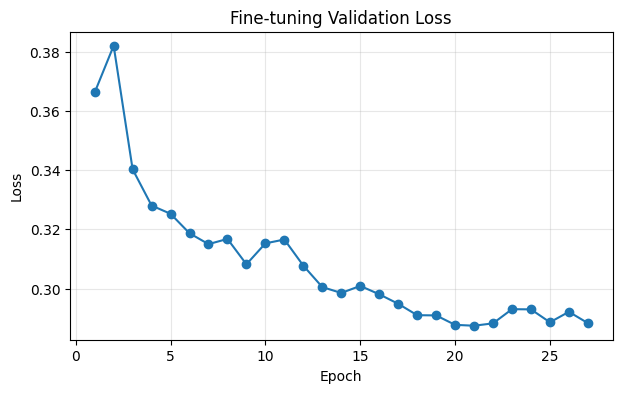

In [ ]:

ft_train_losses = []
ft_val_losses = []
epoches =40

for epoch in range(epoches):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    ft_train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    ft_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{epoches} "
        f"- train_loss: {avg_train_loss:.4f} "
        f"- val_loss: {avg_val_loss:.4f}"
    )

    y_pred, y_true = get_predictions(model, val_loader, device)
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler.step(val_qwk)
    current_lr_head = optimizer.param_groups[0]['lr']
    print(f"  current LR (classifier): {current_lr_head:.2e}")

    early_stopper(val_qwk, model)

    if early_stopper.early_stop:
      print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper.best_score:.4f})")
      break


model.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model_finetuned.pt'))
print("The bset fine-tuning model is downloded successfully")


plot_training_curve(ft_train_losses, title="Fine-tuning Training Loss")
plot_training_curve(ft_val_losses, title="Fine-tuning Validation Loss")

# Ordinal Model (CORN)

In [28]:
!pip install coral-pytorch -q

import os
os.makedirs('/RetinaGrade/CheckPoint', exist_ok=True)

In [31]:
from coral_pytorch.losses import corn_loss
from evalution import evaluate_model, plot_training_curve, get_predictions, compute_metrics, compute_qwk
from early_stopper import EarlyStopping

model_corn = build_model(model_name="efficientnet_b3", num_classes=4, freeze_features=True)



model_corn.to(device)

optimizer_corn = optim.Adam(model_corn.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_corn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_corn, mode='min', factor=0.5, patience=2)

early_stopper_corn = EarlyStopping(
    patience=5,
    min_delta=0.001,
    path='/RetinaGrade/CheckPoint/best_model_corn.pt',
    mode='max'
)


Epoch 1/20 - train_loss: 0.5242 - val_loss: 0.4232
  val macro F1: 0.4454 | val QWK: 0.7791
  current LR: 1.00e-03
  -> Best model saved (max: 0.7791)
Epoch 2/20 - train_loss: 0.4451 - val_loss: 0.4331
  val macro F1: 0.3907 | val QWK: 0.7604
  current LR: 1.00e-03
Epoch 3/20 - train_loss: 0.4295 - val_loss: 0.3760
  val macro F1: 0.4976 | val QWK: 0.7994
  current LR: 1.00e-03
  -> Best model saved (max: 0.7994)
Epoch 4/20 - train_loss: 0.4347 - val_loss: 0.3637
  val macro F1: 0.4512 | val QWK: 0.7826
  current LR: 1.00e-03
Epoch 5/20 - train_loss: 0.4151 - val_loss: 0.3656
  val macro F1: 0.4724 | val QWK: 0.7944
  current LR: 1.00e-03
Epoch 6/20 - train_loss: 0.4254 - val_loss: 0.3816
  val macro F1: 0.4883 | val QWK: 0.8165
  current LR: 1.00e-03
  -> Best model saved (max: 0.8165)
Epoch 7/20 - train_loss: 0.4294 - val_loss: 0.4333
  val macro F1: 0.4308 | val QWK: 0.8009
  current LR: 5.00e-04
Epoch 8/20 - train_loss: 0.4082 - val_loss: 0.3594
  val macro F1: 0.4705 | val QWK: 0.

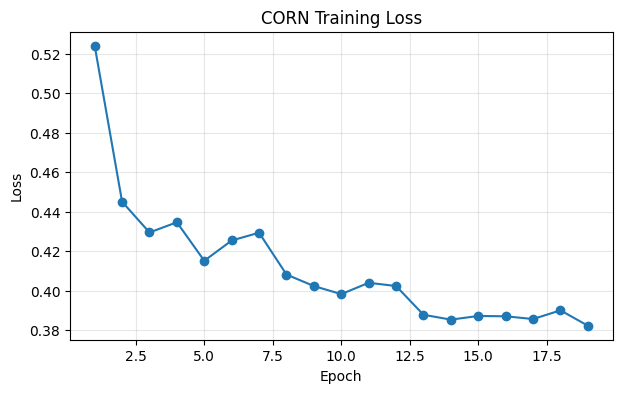

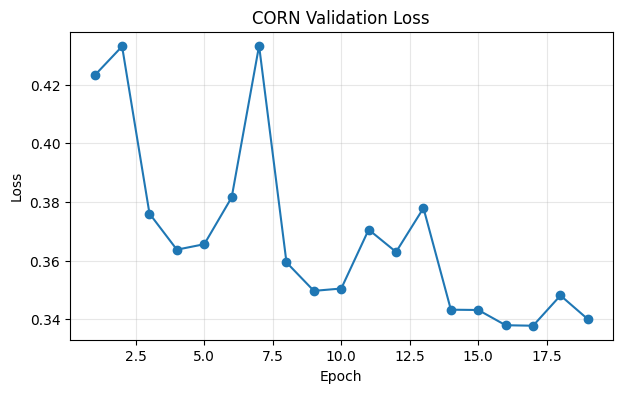

Accuracy:  0.7394
F1 (macro):     0.4996
Recall (macro): 0.5083
Precision (macro): 0.6225
QWK:       0.8339

Per-class report:
               precision    recall  f1-score   support

        No DR       0.94      0.94      0.94       361
         Mild       0.46      0.18      0.25        74
     Moderate       0.60      0.81      0.69       200
       Severe       0.29      0.46      0.36        39
Proliferative       0.82      0.15      0.26        59

     accuracy                           0.74       733
    macro avg       0.62      0.51      0.50       733
 weighted avg       0.76      0.74      0.72       733



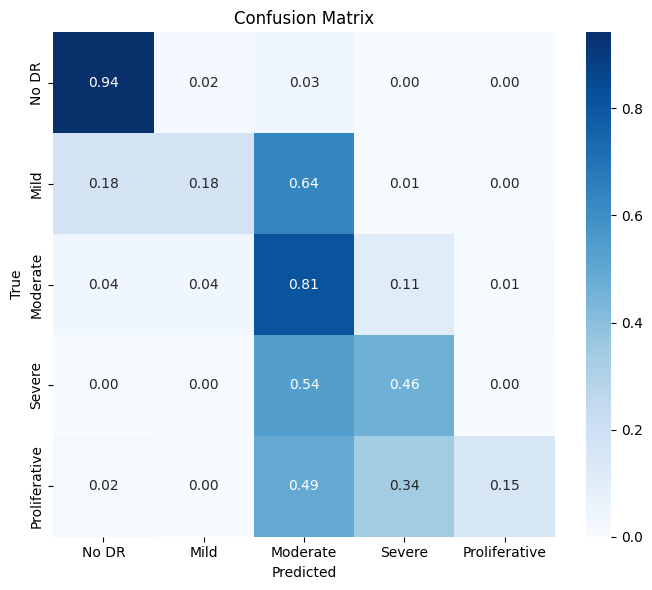

In [32]:
corn_val_losses = []
corn_train_losses = []
epoches = 20

for epoch in range(epoches):

    model_corn.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_corn.zero_grad()
        logits = model_corn(images)
        loss = corn_loss(logits, labels, num_classes=len(grade_labels))
        loss.backward()
        optimizer_corn.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    corn_train_losses.append(avg_train_loss)

    model_corn.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model_corn(images)
            loss = corn_loss(logits, labels, num_classes=len(grade_labels))
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    corn_val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{epoches} - train_loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

    y_pred, y_true = get_predictions_corn(model_corn, val_loader, device, num_classes=len(grade_labels))
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler_corn.step(avg_val_loss)
    current_lr = optimizer_corn.param_groups[0]['lr']
    print(f"  current LR: {current_lr:.2e}")

    early_stopper_corn(val_qwk, model_corn)
    if early_stopper_corn.early_stop:
        print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper_corn.best_score:.4f})")
        break


model_corn.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model_corn.pt'))
plot_training_curve(corn_train_losses, title="CORN Training Loss")
plot_training_curve(corn_val_losses, title="CORN Validation Loss")
final_metrics = evaluate_model_corn(model_corn, val_loader, device, average="macro", plot=True)

#unfreeze

Trainable params: 8,512,227 / 10,702,381 (79.5%)
Epoch 1/40 - train_loss: 0.3717 - val_loss: 0.3261
  val macro F1: 0.5664 | val QWK: 0.8423
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8423)
Epoch 2/40 - train_loss: 0.3410 - val_loss: 0.3184
  val macro F1: 0.5641 | val QWK: 0.8371
  current LR (classifier): 1.00e-04
Epoch 3/40 - train_loss: 0.3279 - val_loss: 0.3109
  val macro F1: 0.5689 | val QWK: 0.8510
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8510)
Epoch 4/40 - train_loss: 0.3163 - val_loss: 0.3081
  val macro F1: 0.6099 | val QWK: 0.8556
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8556)
Epoch 5/40 - train_loss: 0.3038 - val_loss: 0.2988
  val macro F1: 0.5882 | val QWK: 0.8696
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8696)
Epoch 6/40 - train_loss: 0.2912 - val_loss: 0.2965
  val macro F1: 0.6199 | val QWK: 0.8632
  current LR (classifier): 1.00e-04
Epoch 7/40 - train_loss: 0.2832 - val_l

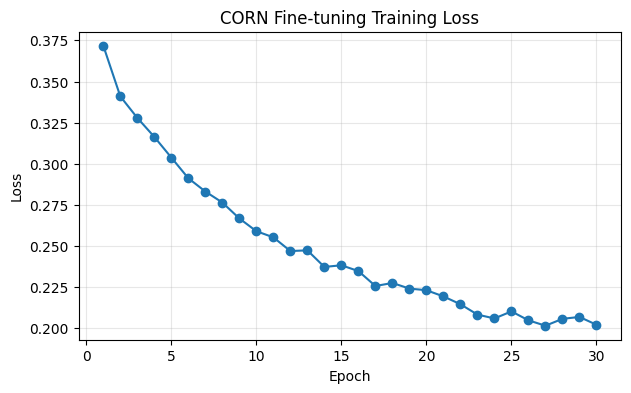

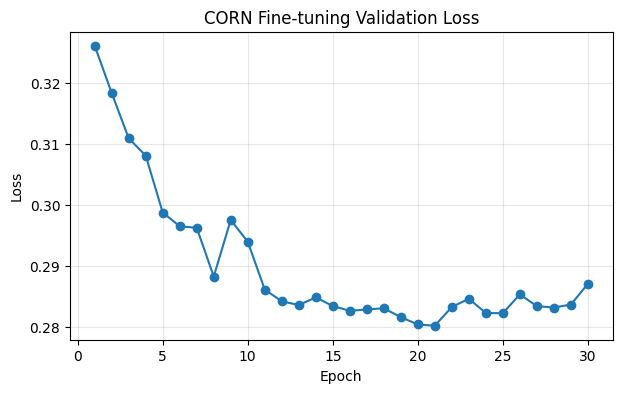

In [33]:
model_corn.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model_corn.pt'))

for layer_idx in [6, 7, 8]:
    for param in model_corn.features[layer_idx].parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model_corn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_corn.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

optimizer_corn = optim.Adam([
    {'params': model_corn.classifier.parameters(), 'lr': 1e-4},
    {'params': model_corn.features[6].parameters(), 'lr': 1e-5},
    {'params': model_corn.features[7].parameters(), 'lr': 1e-5},
    {'params': model_corn.features[8].parameters(), 'lr': 1e-4},
], weight_decay=5e-4)

scheduler_corn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_corn, mode='max', factor=0.5, patience=2)
early_stopper_corn = EarlyStopping(patience=10, min_delta=0.001, path='/RetinaGrade/CheckPoint/best_model_corn_finetuned.pt', mode='max')


ft_corn_train_losses = []
ft_corn_val_losses = []
epoches = 40

for epoch in range(epoches):

    model_corn.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_corn.zero_grad()
        logits = model_corn(images)
        loss = corn_loss(logits, labels, num_classes=len(grade_labels))
        loss.backward()
        optimizer_corn.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    ft_corn_train_losses.append(avg_train_loss)

    model_corn.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model_corn(images)
            loss = corn_loss(logits, labels, num_classes=len(grade_labels))
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    ft_corn_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{epoches} "
        f"- train_loss: {avg_train_loss:.4f} "
        f"- val_loss: {avg_val_loss:.4f}"
    )

    y_pred, y_true = get_predictions_corn(model_corn, val_loader, device, num_classes=len(grade_labels))
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler_corn.step(val_qwk)
    current_lr_head = optimizer_corn.param_groups[0]['lr']
    print(f"  current LR (classifier): {current_lr_head:.2e}")

    early_stopper_corn(val_qwk, model_corn)

    if early_stopper_corn.early_stop:
      print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper_corn.best_score:.4f})")
      break


model_corn.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model_corn_finetuned.pt'))
print("The best fine-tuning CORN model is downloaded successfully")

plot_training_curve(ft_corn_train_losses, title="CORN Fine-tuning Training Loss")
plot_training_curve(ft_corn_val_losses, title="CORN Fine-tuning Validation Loss")

Accuracy:  0.8022
F1 (macro):     0.6511
Recall (macro): 0.6434
Precision (macro): 0.6662
QWK:       0.8890

Per-class report:
               precision    recall  f1-score   support

        No DR       0.96      0.96      0.96       361
         Mild       0.51      0.47      0.49        74
     Moderate       0.73      0.79      0.76       200
       Severe       0.43      0.49      0.46        39
Proliferative       0.70      0.51      0.59        59

     accuracy                           0.80       733
    macro avg       0.67      0.64      0.65       733
 weighted avg       0.80      0.80      0.80       733



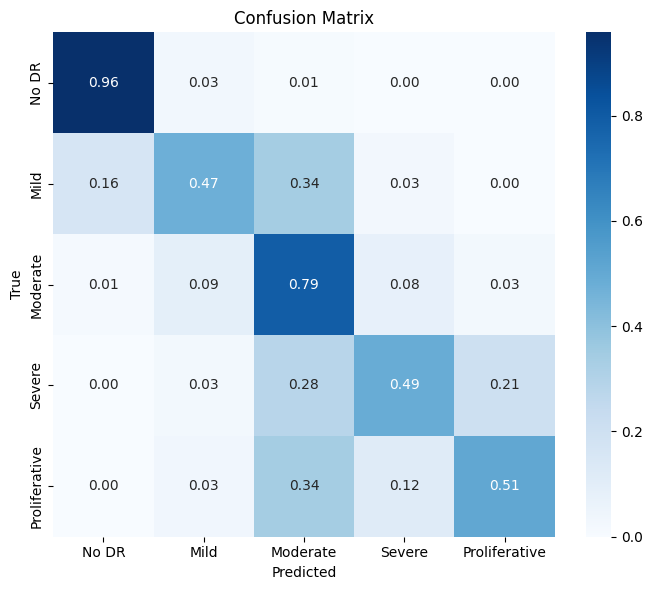

In [34]:
final_metrics = evaluate_model_corn(model_corn, val_loader, device, average="macro", plot=True)

# Grad cam


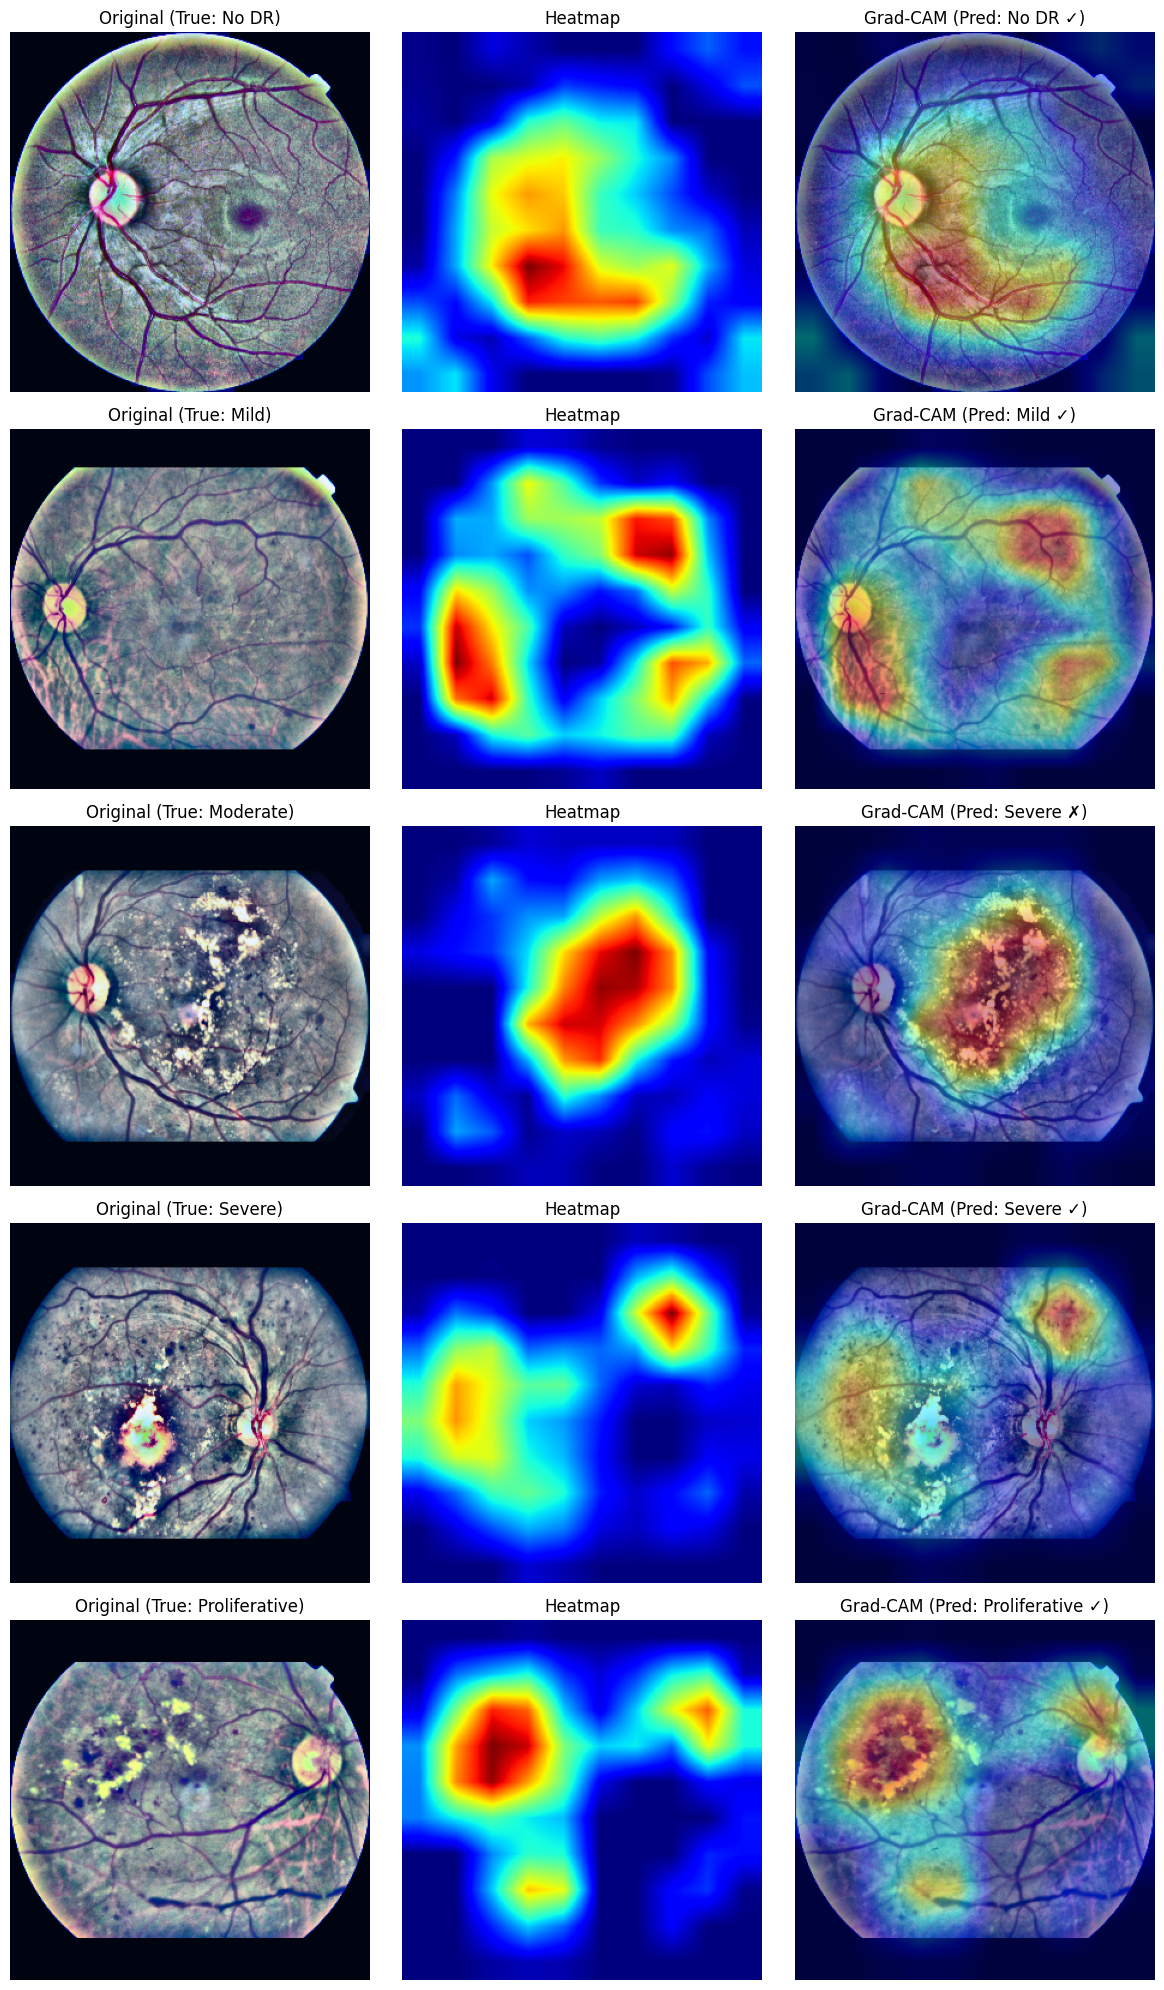

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from grad_cam import GradCAM, overlay_heatmap

samples_per_class = {}
for images, labels in val_loader:
    for img, label in zip(images, labels):
        cls = label.item()
        if cls not in samples_per_class:
            samples_per_class[cls] = img
    if len(samples_per_class) == len(grade_labels):
        break

model.eval()
cam = GradCAM(model, target_layer=model.features[8][0])

n = len(samples_per_class)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = axes.reshape(1, 3)

for row, (true_cls, img) in enumerate(sorted(samples_per_class.items())):
    img_tensor = img.unsqueeze(0).to(device)

    heatmap, pred_class = cam.generate(img_tensor)

    original = img.permute(1, 2, 0).cpu().numpy()
    original = (original - original.min()) / (original.max() - original.min())
    original = (original * 255).astype(np.uint8)

    overlay = overlay_heatmap(original, heatmap)

    true_name = grade_labels[true_cls]
    pred_name = grade_labels[pred_class]
    correct = "(nice work)" if true_cls == pred_class else "(fail)"

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original (True: {true_name})")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title("Heatmap")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"Grad-CAM (Pred: {pred_name} {correct})")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()